## Generate input images for abberation-resilience testing of CFCNN - single point

* In this notebook, we define the tested range of aberrations and use them to generate single-psf images.
* Here we assume strong signals, i.e., virtually noiseless images.
* We study astigmatism, coma, defocus, and spherical aberration.
* Resulting images are saved in `data/` and subsequently processed by `process_inputs_cnn.py`
* PSF model is defined in `psf_toolbox_v2.py`

In [21]:
import numpy as np
from numpy.fft import fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
import h5py
from psf_toolbox_v2 import psf_high_NA_vector
from tqdm import tqdm

import cv2

def scaled_psf_vector(px_size_um: float,
                      NA: float = 1.4,
                      n: float = 1.5,
                      wavelength: float = 0.550,
                      N_pupil: int = 256,
                      pad_factor: int = 8,
                      **A_kwargs) -> np.ndarray:
    """
    Generate a 50x50 PSF from psf_high_NA_vector with given real pixel size.

    Parameters
    ----------
    px_size_um : float
        Pixel size in µm for the final 50x50 image.
    NA, n : float
        Numerical aperture and refractive index.
    wavelength : float
        Wavelength in µm.
    N_pupil, pad_factor : int
        Sampling settings for PSF simulation.
    **A_kwargs : dict
        Aberration coefficients for psf_high_NA_vector.

    Returns
    -------
    np.ndarray : 50x50 PSF normalized to sum = 1.
    """
    # Generate high-resolution PSF
    hires, x, y = psf_high_NA_vector(N_pupil=N_pupil,
                                     pad_factor=pad_factor,
                                     wavelength=wavelength,
                                     NA=NA, n=n,
                                     **A_kwargs)

    dx = x[1] - x[0]  # µm per pixel in simulation
    halfwidth_um = (50 / 2) * px_size_um  # physical half-width for crop
    halfwidth_steps = int(round(halfwidth_um / dx))

    mid = hires.shape[0] // 2
    cropped = hires[
        mid - halfwidth_steps : mid + halfwidth_steps,
        mid - halfwidth_steps : mid + halfwidth_steps
    ]

    # Resize to exactly 50×50 pixels
    scaled = cv2.resize(cropped, (50, 50), interpolation=cv2.INTER_CUBIC)

    # Normalize intensity
    return scaled / scaled.sum()
    

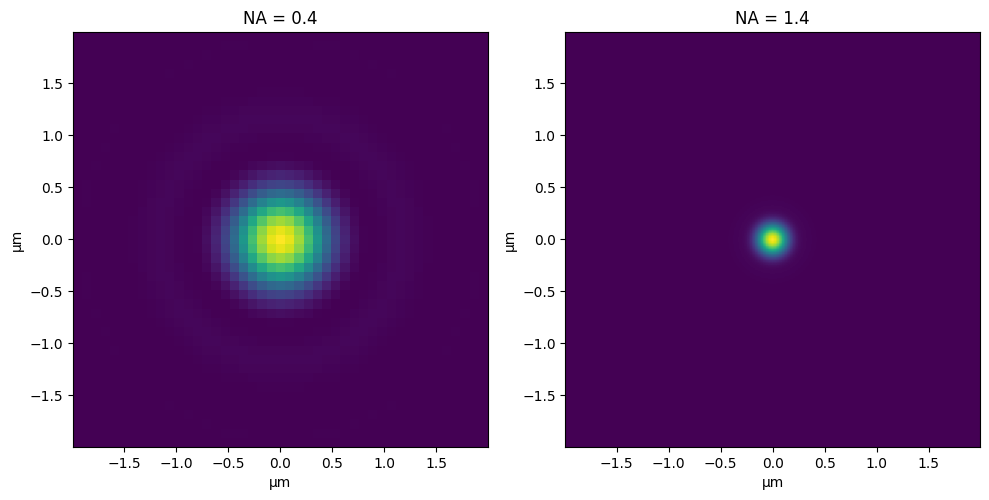

In [22]:
# Compute PSFs
psf_low, x_low, y_low = psf_high_NA_vector(NA=0.4, A_ast=0.0)
psf_high, x_high, y_high = psf_high_NA_vector(NA=1.4, A_ast=0.0)

# Define zoom range in µm
zoom_range = 2.0  # ± range from center

ix_low = np.where((x_low >= -zoom_range) & (x_low <= zoom_range))[0]
iy_low = np.where((y_low >= -zoom_range) & (y_low <= zoom_range))[0]
ix_high = np.where((x_high >= -zoom_range) & (x_high <= zoom_range))[0]
iy_high = np.where((y_high >= -zoom_range) & (y_high <= zoom_range))[0]

# Plot zoomed PSFs
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

im1 = axs[0].imshow(psf_low[np.ix_(iy_low, ix_low)],
                    extent=[x_low[ix_low[0]], x_low[ix_low[-1]],
                            y_low[iy_low[0]], y_low[iy_low[-1]]],
                    origin='lower')
axs[0].set_title("NA = 0.4")
axs[0].set_xlabel("µm")
axs[0].set_ylabel("µm")

im2 = axs[1].imshow(psf_high[np.ix_(iy_high, ix_high)],
                    extent=[x_high[ix_high[0]], x_high[ix_high[-1]],
                            y_high[iy_high[0]], y_high[iy_high[-1]]],
                    origin='lower')
axs[1].set_title("NA = 1.4")
axs[1].set_xlabel("µm")
axs[1].set_ylabel("µm")

plt.tight_layout()
plt.show()

In [25]:
base_size = 50
scale = 4
up_size = base_size * scale

# Coordinates of emitter in 50x50 (center)
x_base, y_base = base_size / 2, base_size / 2
intensity = 1.0

# Upscale coordinates with shift to keep center aligned
shift = (scale - 1) / 2
#shift = int((scale - 1) / 2)
x_up = x_base * scale + shift
y_up = y_base * scale + shift

# Create upscaled image and place emitter
image = np.zeros((up_size, up_size), dtype=np.float32)
image[int(round(y_up)), int(round(x_up))] = intensity


num_psfs = 30
img_size = base_size
abberations = {
    'A_coma_x' :  np.linspace(0.0, 0.3, num_psfs),
    'A_ast' : np.linspace(0.0, 0.3, num_psfs),
    'A_sph' : np.linspace(0.0, 0.3, num_psfs),    
    'A_def' : np.linspace(0.0, 0.3, num_psfs)
}

with h5py.File('data/single_point_psf_for_cnn.h5', 'w') as h5f:
    dset_aber_size = h5f.create_dataset('abberation_size', data = abberations['A_def'])
    dset_reference = h5f.create_dataset('reference', data = image)
    
    for key in abberations:
        print(key)
        A_values = abberations[key]
        psf_stack = np.zeros((A_values.shape[0], img_size, img_size), dtype=np.float32)
        for i, A_ast in tqdm(enumerate(A_values), total=A_values.shape[0]):
            psf = scaled_psf_vector(px_size_um=0.059, NA=1.4, n=1.5, **{key : A_ast})
            psf_stack[i] = psf
        h5f.create_dataset(key, data=psf_stack)

A_coma_x


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:27<00:00,  1.10it/s]


A_ast


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:27<00:00,  1.11it/s]


A_sph


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:27<00:00,  1.11it/s]


A_def


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [00:27<00:00,  1.11it/s]
